In [30]:
import os
import sys
import argparse
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import matplotlib.gridspec as gridspec

# Configuration
plt.style.use('seaborn-v0_8-darkgrid')
mpl.rcParams['figure.dpi'] = 150
sns.set_palette("husl")

In [27]:
# Read the file for urban factors, SWORD reaches, usgs gage heights
sword_urban = gpd.read_file(
    "/work/pi_kandread_umass_edu/swot-urban/1_data_processing/test_usgs_sword_matchups.shp"
)

sword_urban = sword_urban.dropna(axis=1, how='all')
sword_urban.fctimp_mea = sword_urban.fctimp_mea / 100

Saved figure: histograms_reaches_urban.png
Saved stats: histograms_reaches_urban_stats.csv

Statistics Summary:
                   class     column     n     mean   median      std      q25      q75
Total Impervious Surface fctimp_mea 32017 0.036492 0.009507 0.067339 0.002054 0.049834
              Open Space nlcd_21_me 32017 0.031882 0.012442 0.036853 0.003709 0.056971
           Low Intensity nlcd_22_me 32017 0.030332 0.012197 0.040925 0.002262 0.045576
        Medium Intensity nlcd_23_me 32017 0.017743 0.004509 0.032165 0.000999 0.017670
          High Intensity nlcd_24_me 32017 0.007882 0.000622 0.015731 0.000000 0.004830


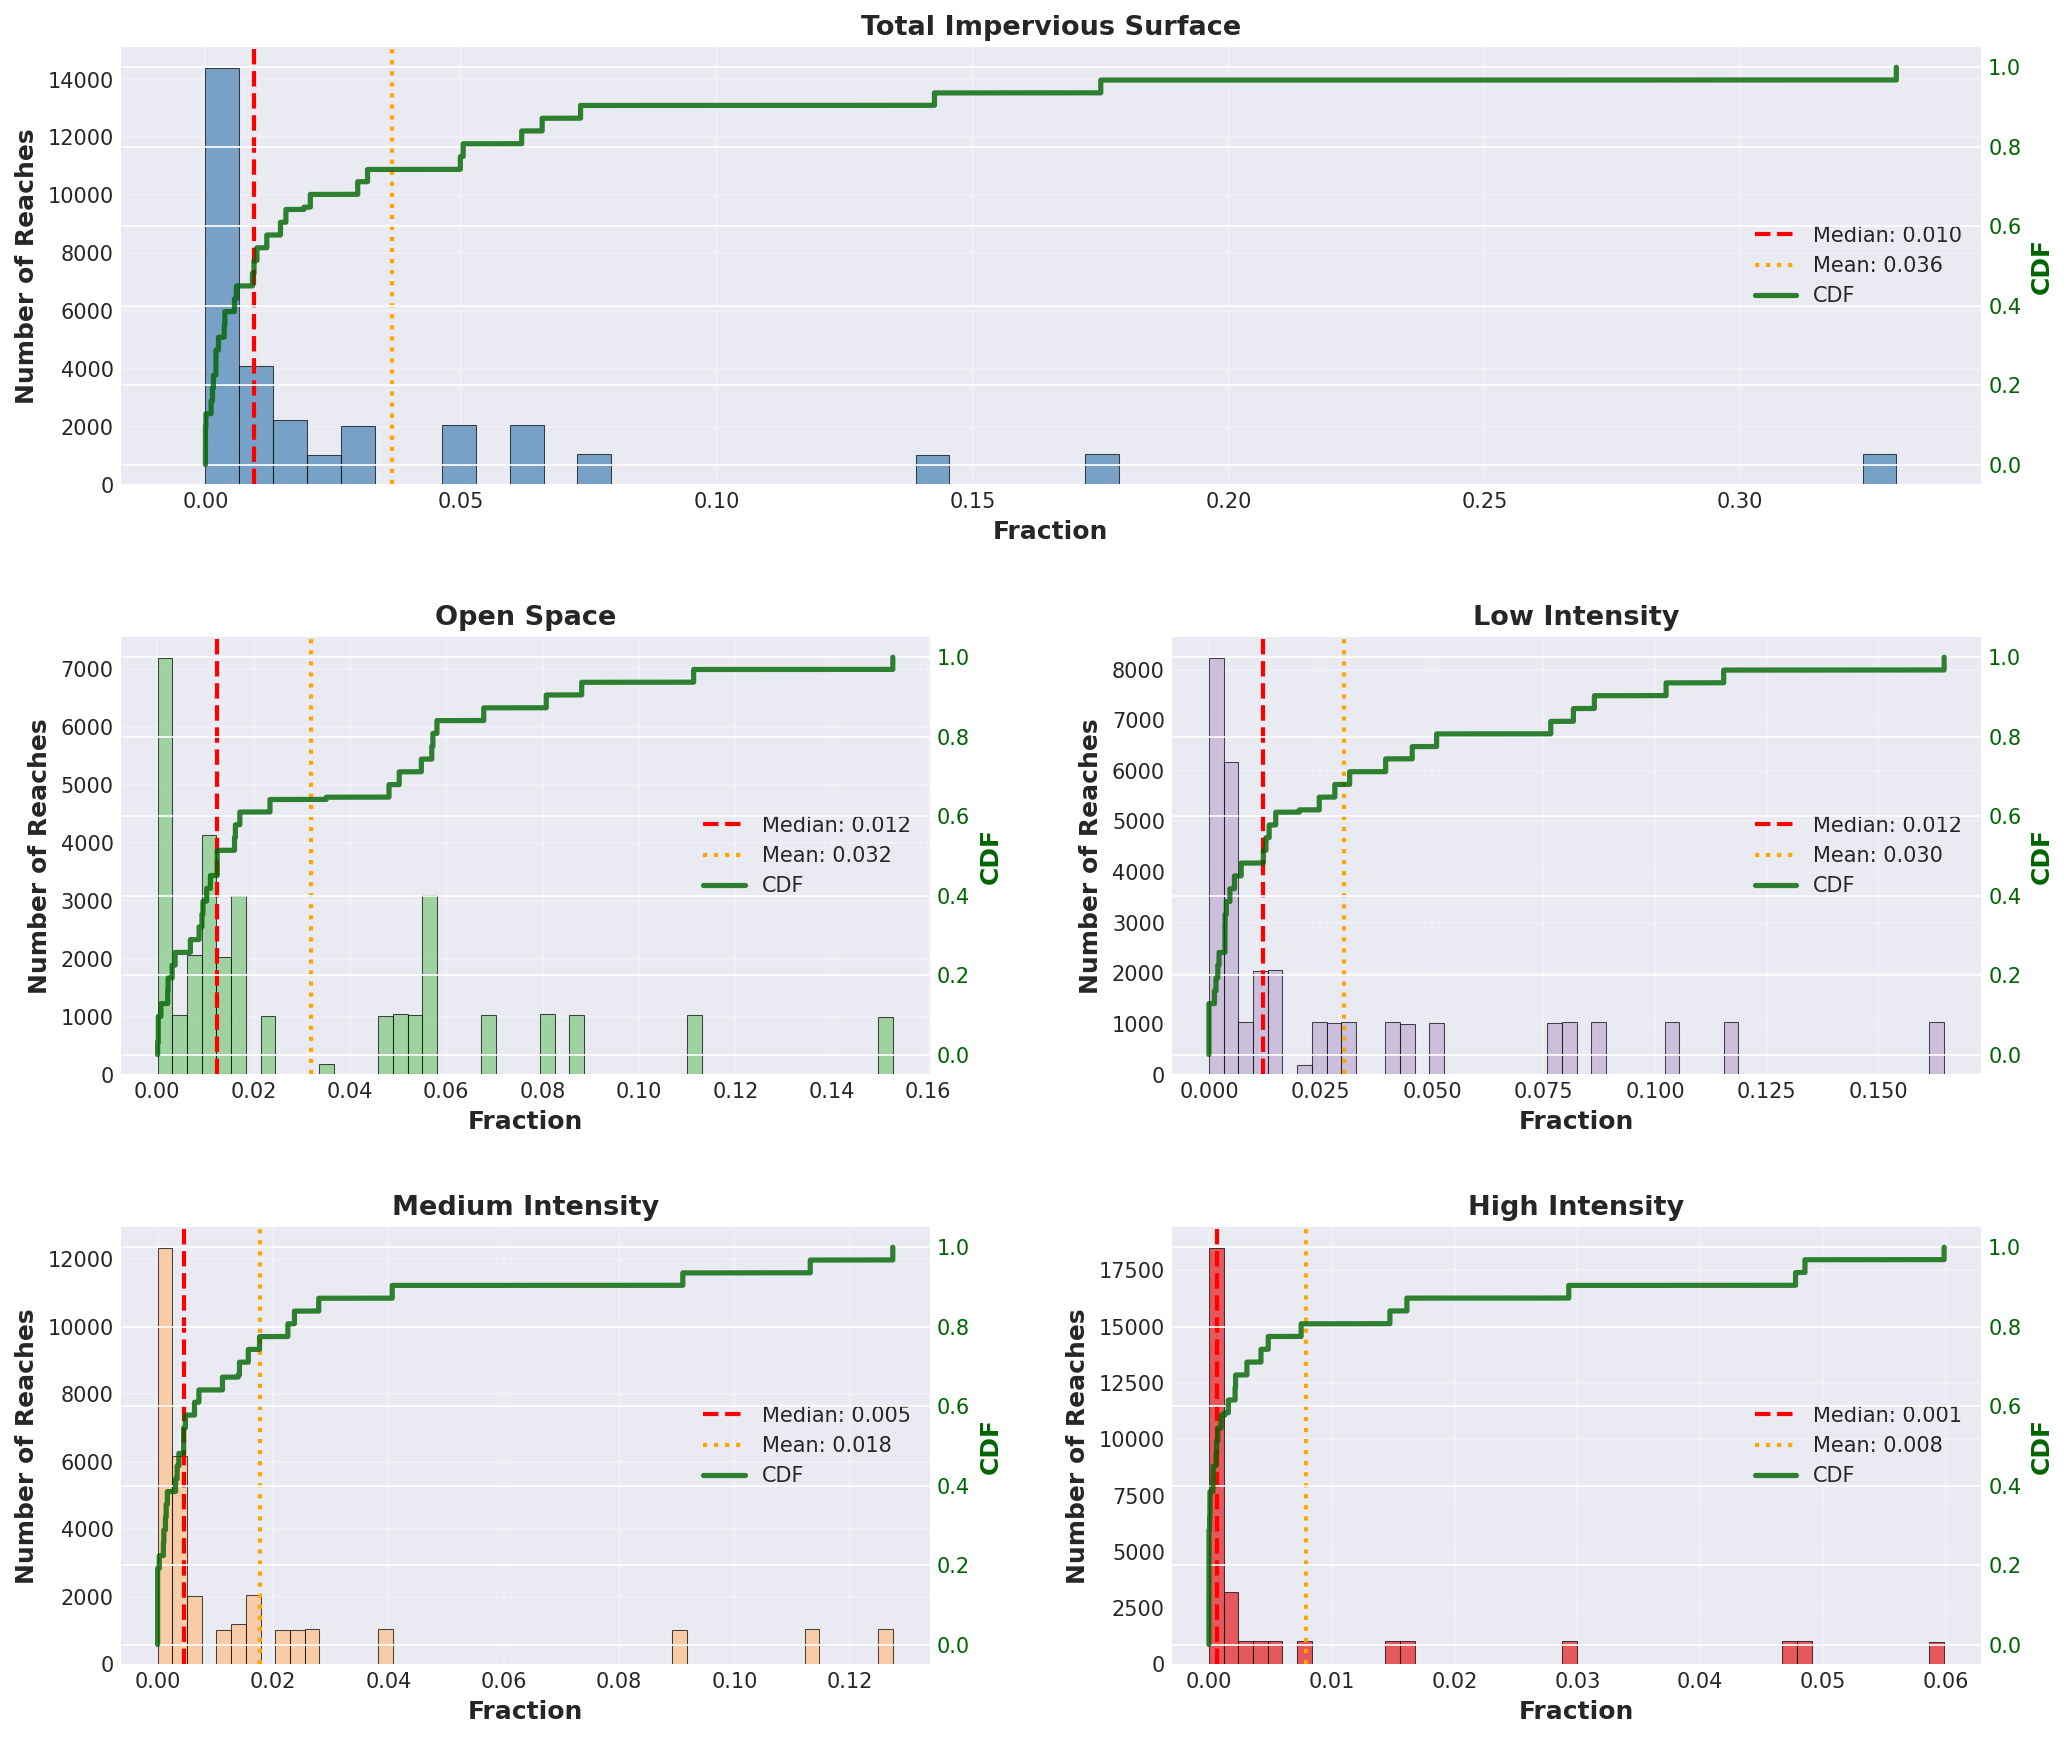

In [37]:
"""
Urban Area Histograms with CDF
"""

def plot_hist_cdf(ax, data, col, title, color='steelblue'):
    """Plot histogram with CDF on twin axis"""
    vals = data[col].dropna()
    if len(vals) == 0:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center')
        return
    
    # Histogram
    ax.hist(vals, bins=50, alpha=0.7, color=color, edgecolor='black', linewidth=0.5)
    ax.axvline(vals.median(), color='red', linestyle='--', linewidth=2, 
               label=f'Median: {vals.median():.3f}')
    ax.axvline(vals.mean(), color='orange', linestyle=':', linewidth=2, 
               label=f'Mean: {vals.mean():.3f}')
    ax.set_xlabel('Fraction', fontweight='bold')
    ax.set_ylabel('Number of Reaches', fontweight='bold')
    ax.set_title(title, fontweight='bold', fontsize=13)
    ax.grid(alpha=0.3)
    
    # CDF
    ax2 = ax.twinx()
    sorted_vals = np.sort(vals)
    cdf = np.arange(1, len(sorted_vals) + 1) / len(sorted_vals)
    ax2.plot(sorted_vals, cdf, 'darkgreen', linewidth=2.5, alpha=0.8, label='CDF')
    ax2.set_ylabel('CDF', fontweight='bold', color='darkgreen')
    ax2.tick_params(axis='y', labelcolor='darkgreen')
    ax2.set_ylim(-0.05, 1.05)
    
    # # Stats box
    # stats = f'n={len(vals):,}\nμ={vals.mean():.3f}\nσ={vals.std():.3f}\nMed={vals.median():.3f}'
    # ax.text(0.98, 0.97, stats, transform=ax.transAxes, fontsize=9, 
    #         va='top', ha='right', family='monospace',
    #         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    # Legend
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='center right', framealpha=0.9)


def create_urban_histograms(data, save_path=None):
    """    
    Parameters:
    -----------
    data : DataFrame
        Data with urban area columns
    save_path : str, optional
        Path to save figure
    
    Returns:
    --------
    fig : matplotlib figure
    stats_df : DataFrame with statistics
    """
    
    # Plot configuration
    plots = [
        ('fctimp_mea', 'Total Impervious Surface', 'steelblue', (0, slice(0, 2))),
        ('nlcd_21_me', 'Open Space', '#7fc97f', (1, 0)),
        ('nlcd_22_me', 'Low Intensity', '#beaed4', (1, 1)),
        ('nlcd_23_me', 'Medium Intensity', '#fdc086', (2, 0)),
        ('nlcd_24_me', 'High Intensity', '#e41a1c', (2, 1))
    ]
    
    # Create figure
    fig = plt.figure(figsize=(16, 14))
    gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.35, wspace=0.3)
    
    # Generate plots
    stats_list = []
    for col, title, color, pos in plots:
        if col not in data.columns:
            print(f"Warning: {col} not found, skipping")
            continue
        
        # Create subplot
        if isinstance(pos[1], slice):
            ax = fig.add_subplot(gs[pos[0], pos[1]])
        else:
            ax = fig.add_subplot(gs[pos[0], pos[1]])
        
        # Plot
        plot_hist_cdf(ax, data, col, title, color)
        
        # Collect statistics
        vals = data[col].dropna()
        if len(vals) > 0:
            stats_list.append({
                'class': title,
                'column': col,
                'n': len(vals),
                'mean': vals.mean(),
                'median': vals.median(),
                'std': vals.std(),
                'q25': vals.quantile(0.25),
                'q75': vals.quantile(0.75)
            })
    
    # Save if path provided
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"Saved figure: {save_path}")
        
        # Save statistics
        stats_file = save_path.replace('.png', '_stats.csv')
        stats_df = pd.DataFrame(stats_list)
        stats_df.to_csv(stats_file, index=False, float_format='%.4f')
        print(f"Saved stats: {stats_file}")
    
    # Create stats DataFrame
    stats_df = pd.DataFrame(stats_list)
    
    # Display statistics
    print("\nStatistics Summary:")
    print("="*80)
    print(stats_df.to_string(index=False))
    print("="*80)
    
    return fig, stats_df

fig, stats = create_urban_histograms(sword_urban, save_path='histograms_reaches_urban.png')
plt.show()